In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from reweighting import x_samps, x_resampled

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_temp_pymc\reweighting.py:22: RuntimeWarning: overflow encountered in exp
  weights = np.exp(-delta_u[:, warmup:, ] + v_k[:, warmup:, None])


In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["num_chains"]))
print(config_str)

N50_H100_delta_c2_num_samples1000_num_chains5_a1.5_b0.27_dt0.0008_mt3_nt20_ndt700_nhmc1_dE50


In [3]:
# samples = np.load(f"../../../../output/age_depth_pymc/samples_{config_str}.npy")
# print(np.shape(samples))
iData = az.from_netcdf(f"../../../../output/age_depth_temp_pymc/samples_{config_str}.nc")
samples = iData.posterior['sed_rates'].values
bias_values = iData.sample_stats['bias_value'].values
delF = iData.sample_stats['delta_F'].values
acceptance = iData.sample_stats['acceptance_rate'].values
energy_values = -iData.sample_stats['lp'].values


resampled_samples = x_resampled

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

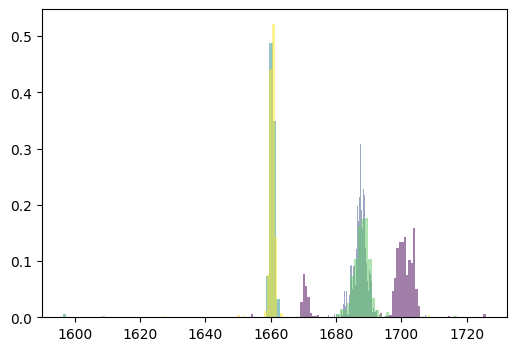

In [5]:
CV_values = data["theta"] - config["delta_c"] * np.sum(samples[:, :, :int(config["N"]/2)], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["num_chains"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

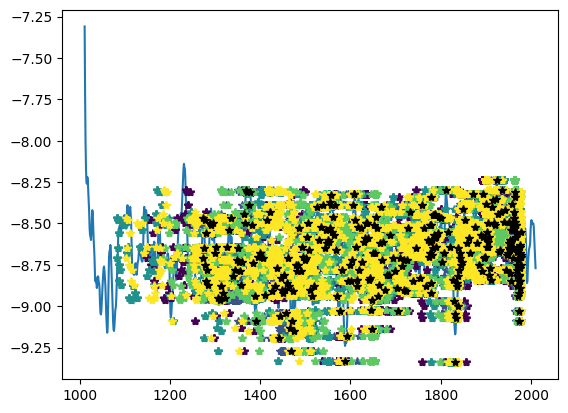

In [6]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["num_chains"]):
    variables = samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["delta_c"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [7]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.27   0.94    0.96     3.52       0.40     0.11      6.34     38.51   
x[1]    2.34   2.17    0.00     5.42       0.93     0.24      6.04     10.46   
x[2]    2.32   2.78    0.00     6.68       1.20     0.27      6.23      9.72   
x[3]    7.98   8.99    0.04    24.83       3.95     2.53      6.25     20.56   
x[4]   12.29   8.32    0.00    23.14       3.61     1.31      5.93     27.81   
x[5]    2.65   2.05    0.01     5.77       0.66     0.22      8.11     83.02   
x[6]    9.50   7.05    0.00    20.77       3.01     1.07      6.26     10.74   
x[7]    7.29   7.98    0.00    22.60       3.43     1.71      5.67     10.66   
x[8]    3.59   2.60    0.06     7.05       0.70     0.52     13.49     51.78   
x[9]    2.86   2.96    0.00     6.97       1.00     0.28      7.16     23.22   
x[10]   3.62   3.43    0.00     9.26       1.39     0.45      6.42     10.53   
x[11]   7.67   5.08    0.15    15.08    

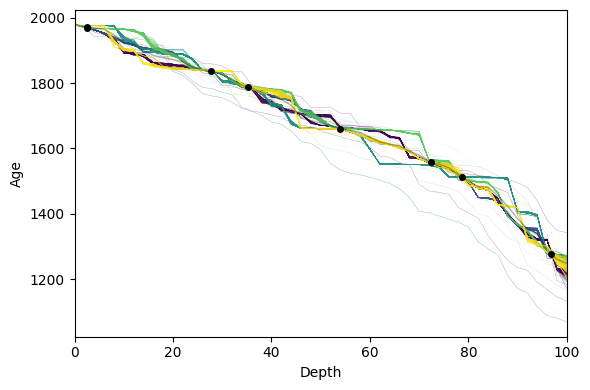

In [8]:
cumulative_sums = np.cumsum(samples[:, :,:], axis=2) * config["delta_c"]
zeros = np.zeros((*samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(samples[0,:,0])
for i in range(config["num_chains"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()